In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [3]:
adata.obs['progression'] = adata.obs['patient'].map({
 'E30': 'Fast',
 'E26': 'Slow',
 'E15': 'Slow',
 'E21': 'Slow',
 'E43': 'Fast',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E24': 'Slow',
 'E22': 'Fast',
 'E45': 'Fast',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E23': 'Slow',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Fast',
 'E18': 'Slow',
 'E20': 'Slow',
 'E32': 'Fast',
 'E46': 'Fast',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'})

In [4]:
adata = adata[adata.obs['annot_final'].isin([
     'CD8 Tem Cell',
     'Tactiv Cell',
     'GZMK+ CD8 T progenitor ex Cell',
     'Th17/Tc17',
     'Tc17',
     'CD8 Cytotoxic T Cell',
     'CD8 HSP T cell',
     'Tprolif Cell',
     'T naive/early memory Cell',
     'Terminal CD8 Tex Cell',
])]

In [5]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

/tmp/ipykernel_2961/3600024150.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)


In [6]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [7]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

In [8]:
clonotype_timepoint = adata.obs[['clonotype_patient','timepoint']].value_counts(
    
).reset_index().pivot(columns='timepoint',index='clonotype_patient',values=0).fillna(0)

clonotype_timepoint = clonotype_timepoint.apply(lambda x: np.where(x != 0, 1, 0))

# Nonshared clonotypes

In [9]:
b_clonotypes = clonotype_timepoint[(clonotype_timepoint['F1'] == 0) & (
    clonotype_timepoint['F2'] == 0)].index.tolist()
f1_clonotypes = clonotype_timepoint[(clonotype_timepoint['B'] == 0) & (
    clonotype_timepoint['F2'] == 0)].index.tolist()
f2_clonotypes = clonotype_timepoint[(clonotype_timepoint['F1'] == 0) & (
    clonotype_timepoint['B'] == 0)].index.tolist()

In [10]:
nonshared_clonotypes = b_clonotypes + f1_clonotypes + f2_clonotypes

In [11]:
import random
random.seed(42)
temp_list = []
for i in adata.obs['sample_x'].unique():
    temp = adata[adata.obs['sample_x'] == i]
    if len(temp) < 100:
        temp_list.append(temp)
    else:
        subsample_obs = random.sample(temp.obs_names.tolist(), 100)
        temp_list.append(temp[subsample_obs,:])

In [12]:
import anndata as ad
subsample = ad.concat(temp_list)

In [13]:
nonshared_counts = pd.concat([
    subsample[
    subsample.obs['clonotype_patient'].isin(nonshared_clonotypes) & (
        subsample.obs['progression'] == 'Fast'
    )].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0),
    subsample[
    subsample.obs['clonotype_patient'].isin(nonshared_clonotypes) & (
        subsample.obs['progression'] == 'Slow'
    )].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0)
]).fillna(0)

Text(0.5, 1.0, 'Phenotypic Distribution of\n Nonshared Clones, Subsampled')

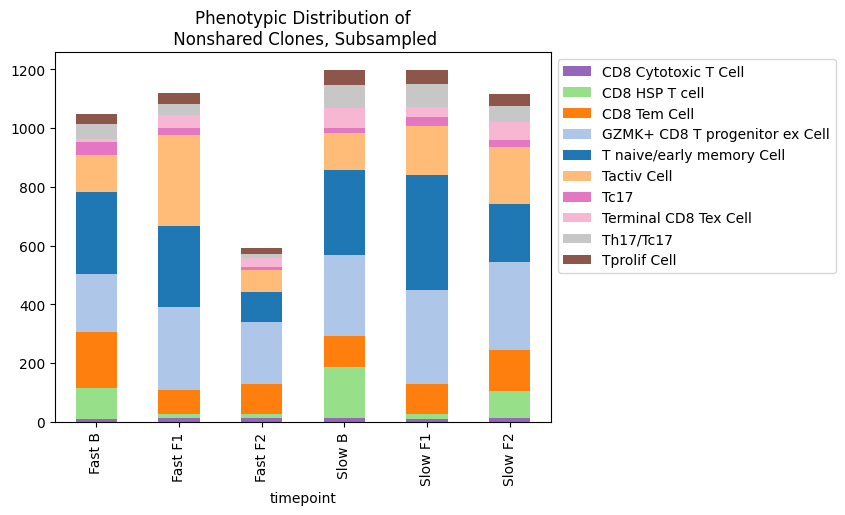

In [14]:
ax=nonshared_counts.plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels([
    'Fast B','Fast F1','Fast F2',
    'Slow B','Slow F1','Slow F2'
                 ])
ax.set_title('Phenotypic Distribution of\n Nonshared Clones, Subsampled')

Text(0.5, 1.0, 'Phenotypic Distribution of\n Nonshared Clones, Subsampled')

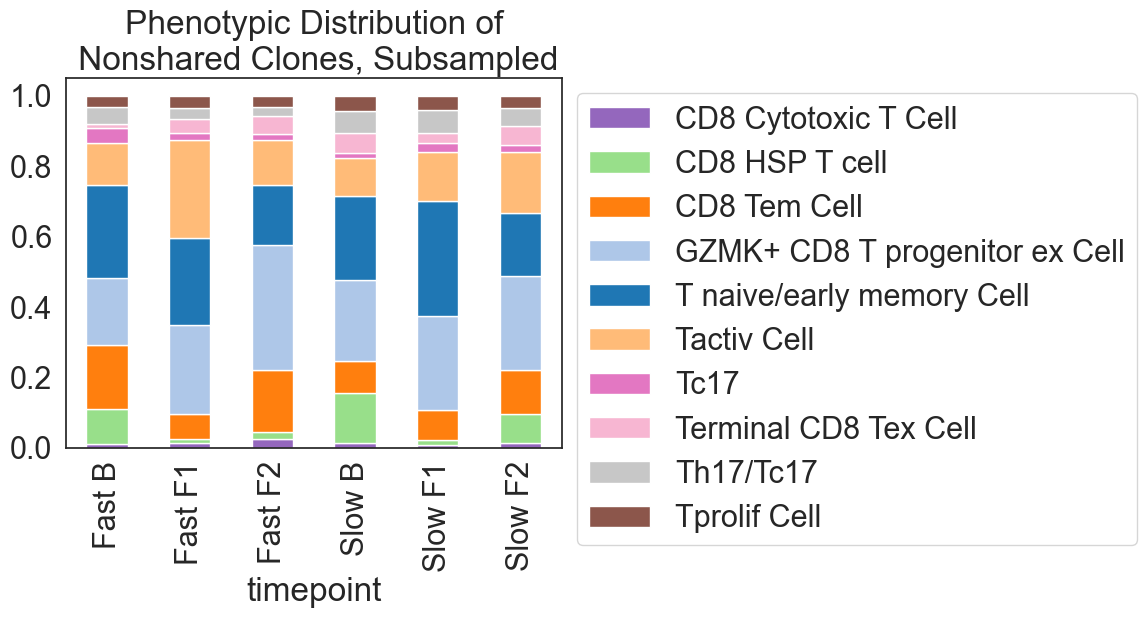

In [15]:
sns.set(font_scale=2)
sns.set_style('white')
ax=nonshared_counts.div(nonshared_counts.sum(axis=1),axis=0).plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels([
    'Fast B','Fast F1','Fast F2',
    'Slow B','Slow F1','Slow F2'
                 ])
ax.set_title('Phenotypic Distribution of\n Nonshared Clones, Subsampled')

# Shared clonotypes

In [16]:
bf1_clonotypes = clonotype_timepoint[(clonotype_timepoint['B'] == 1) & (
    clonotype_timepoint['F1'] == 1)].index.tolist()
f1f2_clonotypes = clonotype_timepoint[(clonotype_timepoint['F2'] == 1) & (
    clonotype_timepoint['F1'] == 1)].index.tolist()

## B-F1

In [17]:
bf1_counts = pd.concat([
    subsample[
    subsample.obs['clonotype_patient'].isin(bf1_clonotypes) & (
        subsample.obs['progression'] == 'Fast'
    )].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0),
    subsample[
    subsample.obs['clonotype_patient'].isin(bf1_clonotypes) & (
        subsample.obs['progression'] == 'Slow'
    )].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0)
]).fillna(0)

Text(0.5, 1.0, 'Phenotypic Distribution of\n B-F1 Clones, Subsampled')

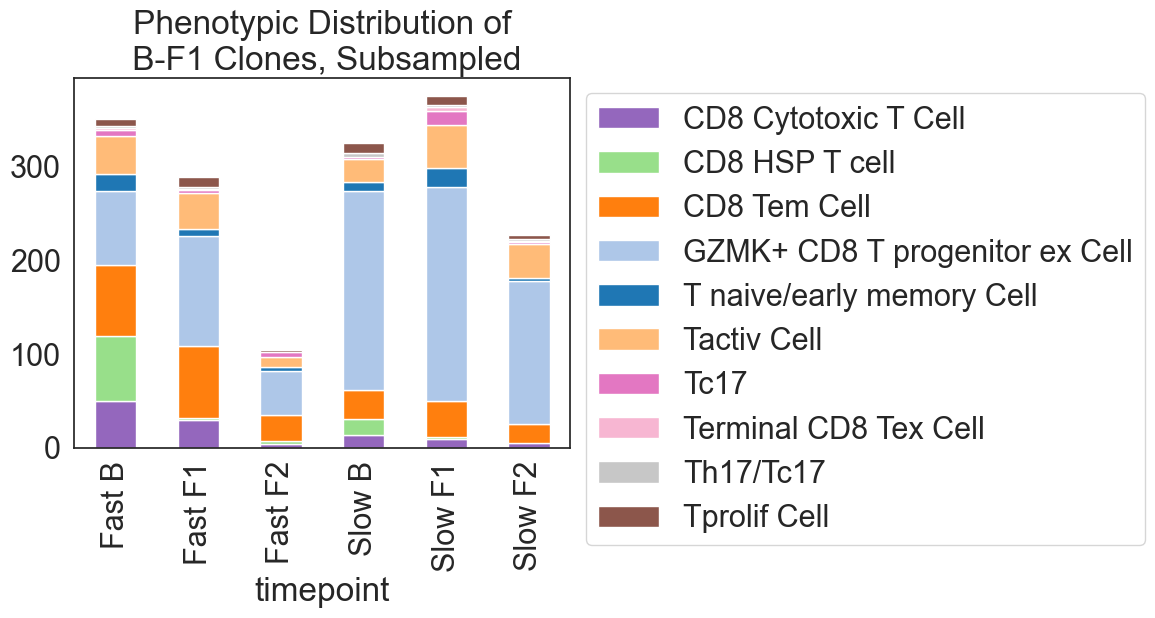

In [18]:
sns.set(font_scale=2)
sns.set_style('white')
ax=bf1_counts.plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2'
                 ])
ax.set_title('Phenotypic Distribution of\n B-F1 Clones, Subsampled')

Text(0.5, 1.0, 'Phenotypic Distribution of\n B-F1 Shared Clones, Subsampled')

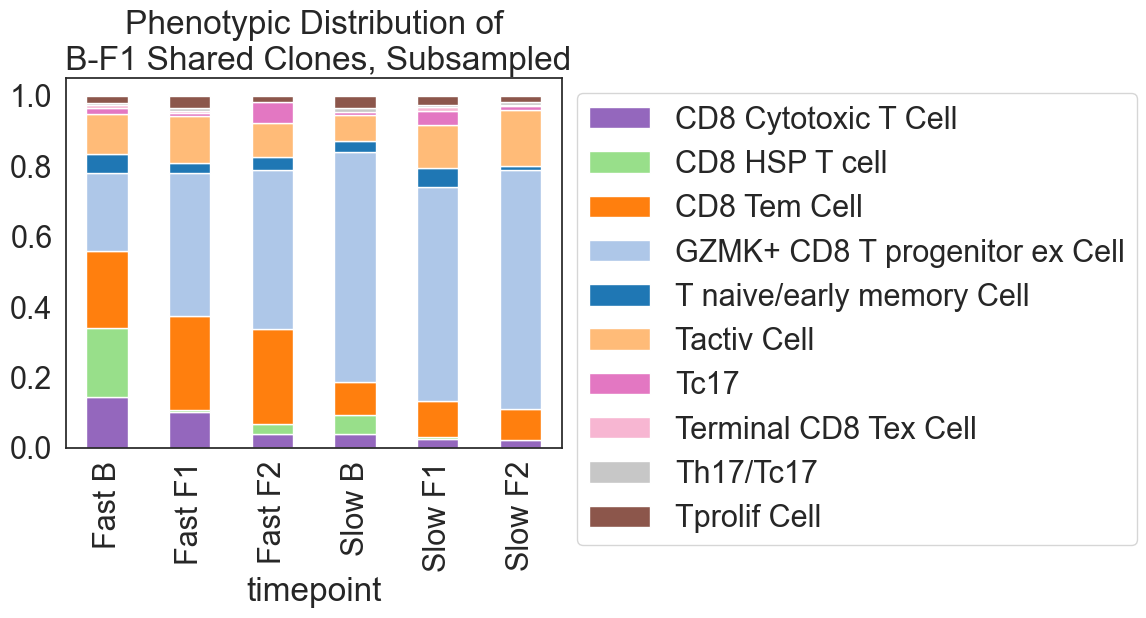

In [19]:
ax=bf1_counts.div(bf1_counts.sum(axis=1),axis=0).plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2',
                 ])
ax.set_title('Phenotypic Distribution of\n B-F1 Shared Clones, Subsampled')

## F1-F2

In [20]:
f1f2_counts = pd.concat([
    subsample[
    subsample.obs['clonotype_patient'].isin(f1f2_clonotypes) & (
        subsample.obs['progression'] == 'Fast'
    )].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0),
    subsample[
    subsample.obs['clonotype_patient'].isin(f1f2_clonotypes) & (
        subsample.obs['progression'] == 'Slow'
    )].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0)
]).fillna(0)

Text(0.5, 1.0, 'Phenotypic Distribution of\n F1-F2 Clones, Subsampled')

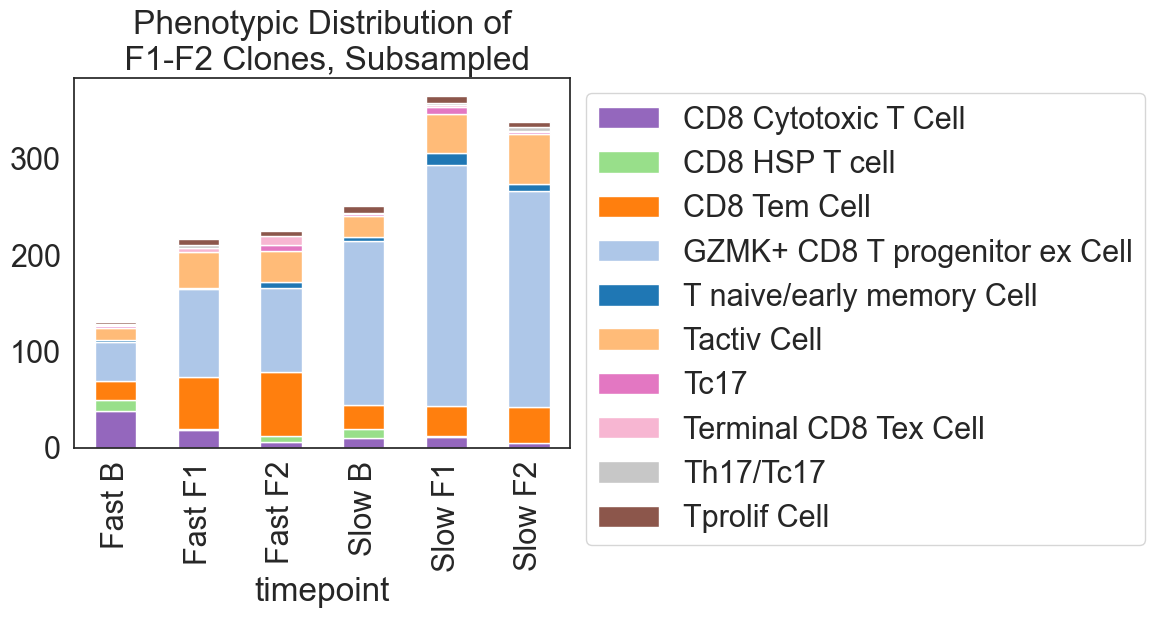

In [21]:
ax=f1f2_counts.plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2'
                 ])
ax.set_title('Phenotypic Distribution of\n F1-F2 Clones, Subsampled')

Text(0.5, 1.0, 'Phenotypic Distribution of\n F1-F2 Shared Clones, Subsampled')

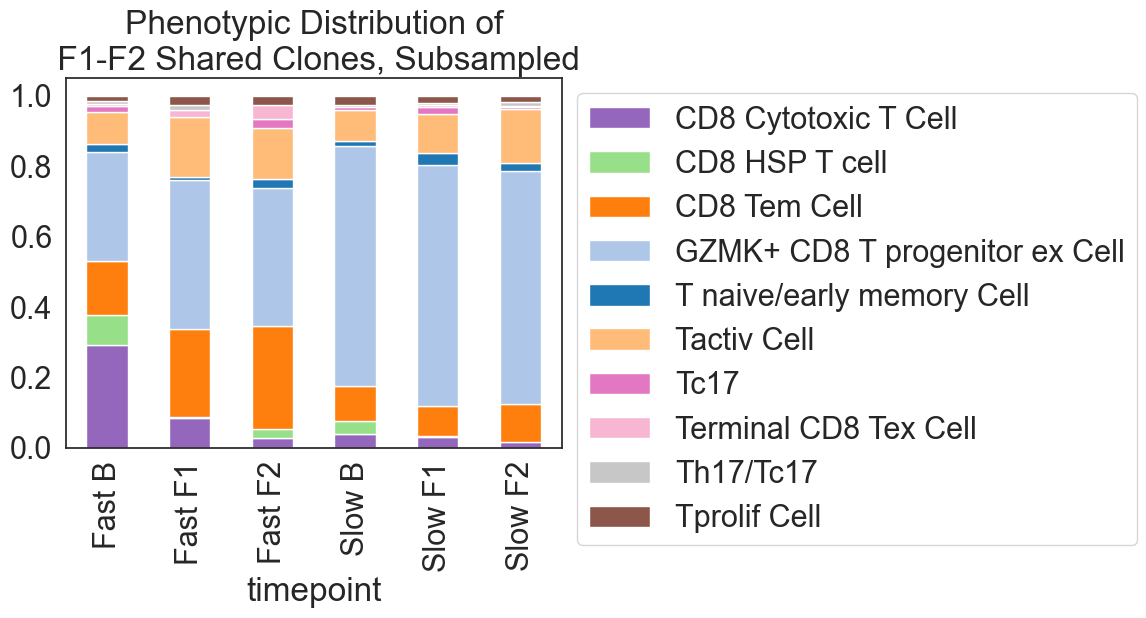

In [22]:
ax=f1f2_counts.div(f1f2_counts.sum(axis=1),axis=0).plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2',
                 ])
ax.set_title('Phenotypic Distribution of\n F1-F2 Shared Clones, Subsampled')

# All time points

In [23]:
all_tp = list(set(bf1_clonotypes) & set(f1f2_clonotypes))

In [24]:
len(all_tp)

475

In [25]:
all_tp_counts = pd.concat([
    subsample[
    subsample.obs['clonotype_patient'].isin(all_tp) & (
        subsample.obs['progression'] == 'Fast'
    )].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0),
    subsample[
    subsample.obs['clonotype_patient'].isin(all_tp) & (
        subsample.obs['progression'] == 'Slow'
    )].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0)
]).fillna(0)

Text(0.5, 1.0, 'Phenotypic Distribution of\n All Time Points Shared Clones, Subsampled')

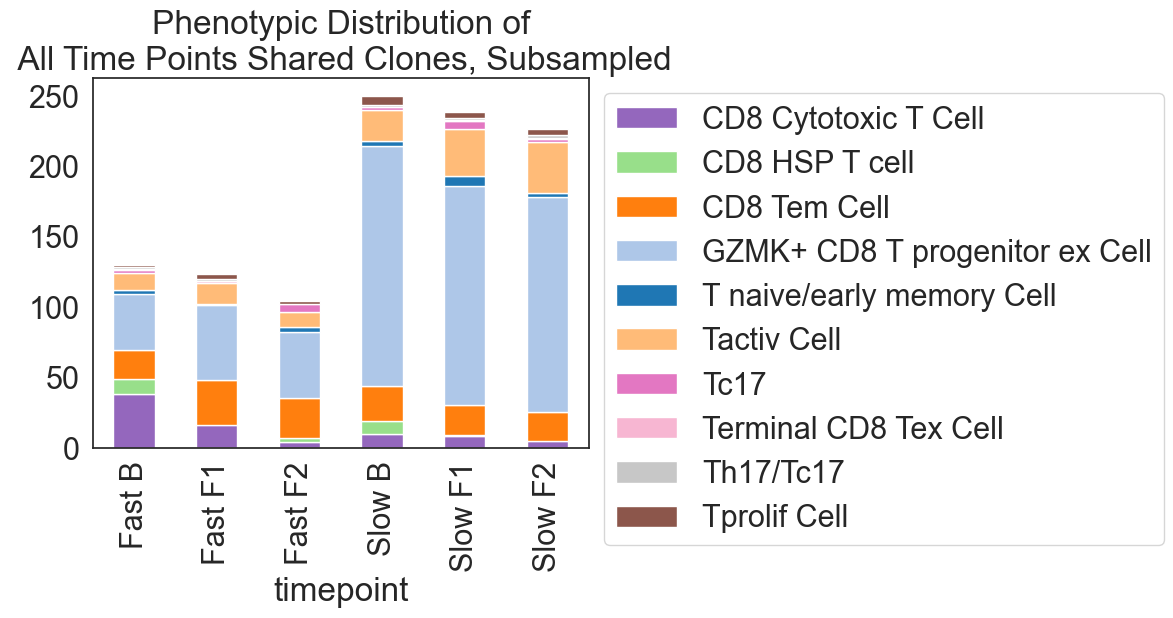

In [26]:
ax=all_tp_counts.plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2'
                 ])
ax.set_title('Phenotypic Distribution of\n All Time Points Shared Clones, Subsampled')

Text(0.5, 1.0, 'Phenotypic Distribution of\n All Time Points Shared Clones, Subsampled')

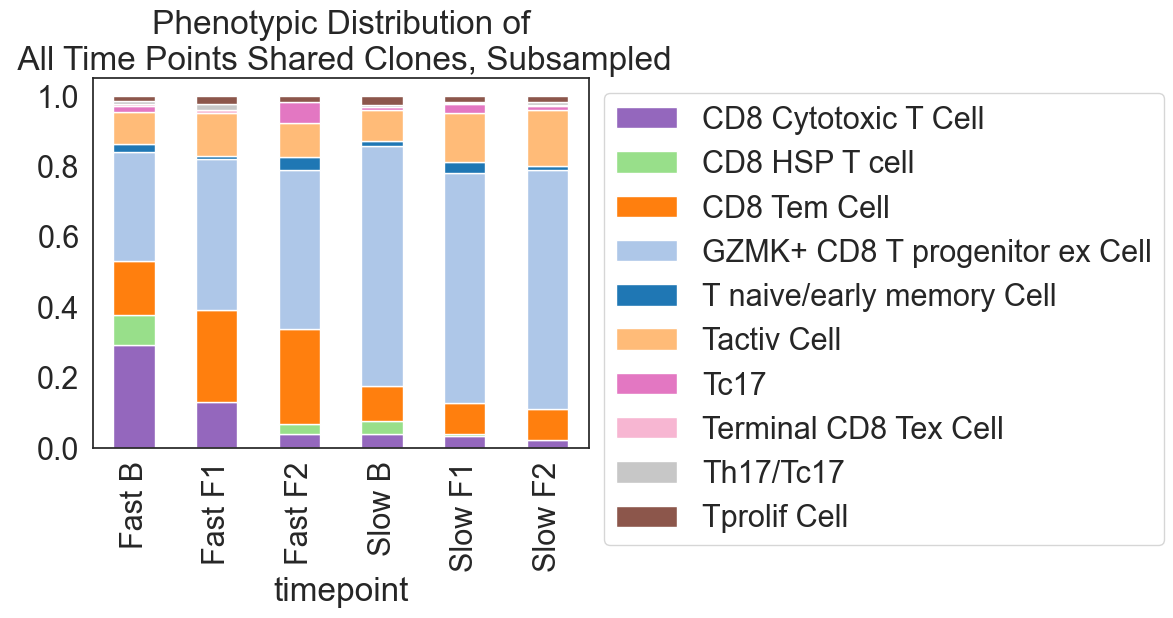

In [27]:
ax=all_tp_counts.div(all_tp_counts.sum(axis=1),axis=0).plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2',
                 ])
ax.set_title('Phenotypic Distribution of\n All Time Points Shared Clones, Subsampled')

# Nonshared with all shared

In [28]:
all_tp_counts_combined = pd.concat([all_tp_counts.iloc[[0,1,2]].sum(axis=0),
           all_tp_counts.iloc[[3,4,5]].sum(axis=0)],axis=1).T
all_tp_counts_combined.index=['All Time Points Fast','All Time Points Slow']

In [29]:
nonshared_counts_combined = pd.concat([nonshared_counts.iloc[[0,1,2]].sum(axis=0),
           nonshared_counts.iloc[[3,4,5]].sum(axis=0)],axis=1).T
nonshared_counts_combined.index=['Non-Shared Fast','Non-Shared Slow']

In [30]:
mixed_df = pd.concat([nonshared_counts_combined.iloc[[0]],
           all_tp_counts_combined.iloc[[0]],
           nonshared_counts_combined.iloc[[1]],
           all_tp_counts_combined.iloc[[1]]],axis=0)

In [31]:
mixed_df.div(mixed_df.sum(axis=1),axis=0)

annot_final,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell
Non-Shared Fast,0.014130,0.047101,0.135507,0.251087,0.236957,0.185870,0.027174,0.032246,0.036957,0.032971
All Time Points Fast,0.162465,0.039216,0.224090,0.392157,0.022409,0.103641,0.022409,0.005602,0.008403,0.019608
Non-Shared Slow,0.010253,0.081173,0.098832,0.254343,0.250071,0.139277,0.020222,0.046141,0.059527,0.040159
All Time Points Slow,0.032213,0.014006,0.092437,0.670868,0.019608,0.127451,0.014006,0.002801,0.005602,0.021008


Text(0.5, 1.0, 'Phenotypic Distribution of\nShared and Non-Shared Clones, Subsampled')

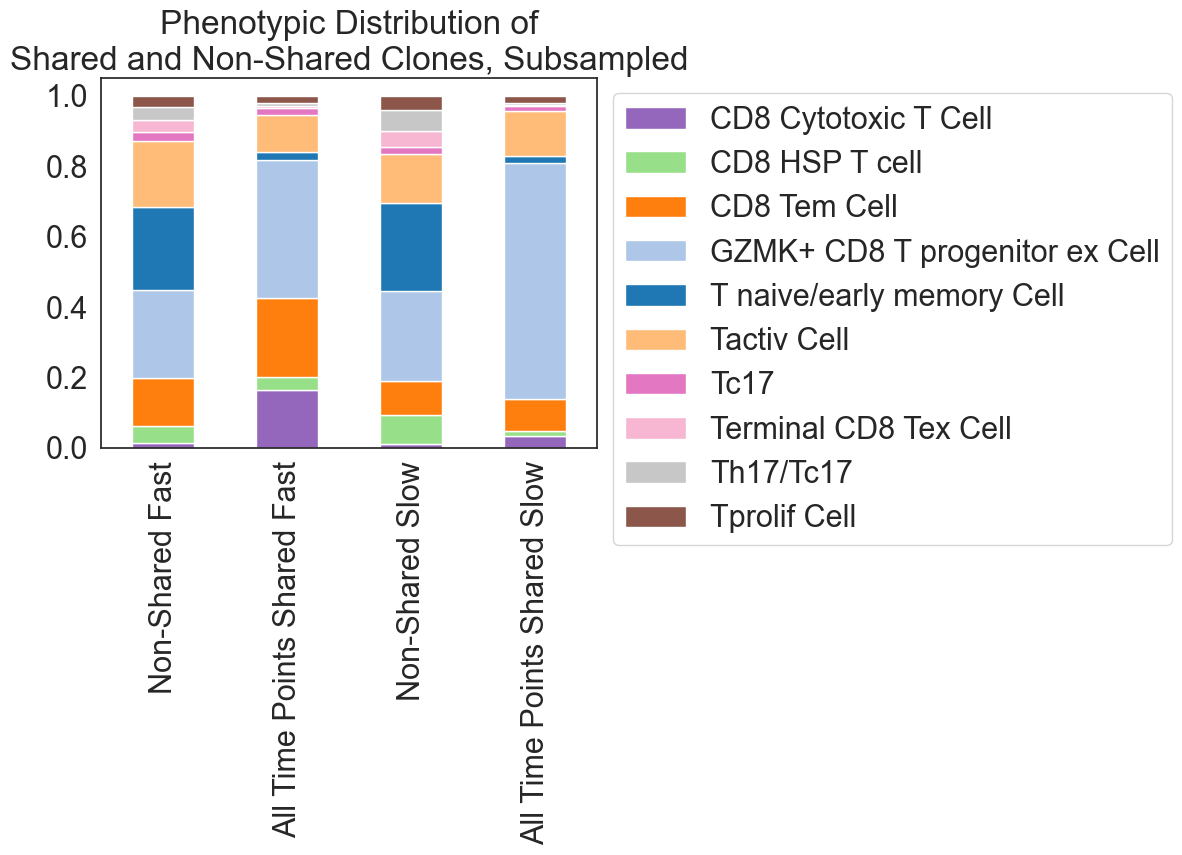

In [32]:
ax=mixed_df.div(mixed_df.sum(axis=1),axis=0).plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Non-Shared Fast','All Time Points Shared Fast',
                    'Non-Shared Slow','All Time Points Shared Slow'
                 ])
ax.set_title('Phenotypic Distribution of\nShared and Non-Shared Clones, Subsampled')